## 1. Imports

In [16]:
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.1
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [17]:
CONFIG = {
    'ROOT_DIR': r'D:\Leaf dataset 2\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)',
    'OUTPUT_DIR': r'D:\Leaf dataset 2\outputs\MobileNetV1',
    'IMG_SIZE': 224,
    'BATCH_SIZE': 32,
    'EPOCHS': 30,
    'NUM_CLASSES': 38,
    'LEARNING_RATE': 1e-3,
    'WIDTH_MULTIPLIER': 1.0,   # scale filters: 0.25 / 0.5 / 0.75 / 1.0
    'SEED': 42,
}

tf.random.set_seed(CONFIG['SEED'])
np.random.seed(CONFIG['SEED'])

TRAIN_DIR = os.path.join(CONFIG['ROOT_DIR'], 'train')
VALID_DIR = os.path.join(CONFIG['ROOT_DIR'], 'valid')
OUT_DIR   = CONFIG['OUTPUT_DIR']
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE    = CONFIG['IMG_SIZE']
BATCH_SIZE  = CONFIG['BATCH_SIZE']
EPOCHS      = CONFIG['EPOCHS']
NUM_CLASSES = CONFIG['NUM_CLASSES']
LR          = CONFIG['LEARNING_RATE']

print('Config loaded ✅')

Config loaded ✅


## 3. Data Loading
> No `test` folder in dataset — `valid` set is used for both training validation and final evaluation.

In [18]:
def build_datasets():
    train_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=True,
        seed=CONFIG['SEED'],
    )
    valid_ds = tf.keras.utils.image_dataset_from_directory(
        VALID_DIR,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=False,
    )

    class_names = train_ds.class_names
    print(f'\n✅  Found {len(class_names)} classes.')
    print('ℹ️  Using valid set for final evaluation (no test folder).')

    augmentation = tf.keras.Sequential([
        layers.RandomFlip('horizontal_and_vertical'),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.15),
        layers.RandomBrightness(0.1),
        layers.RandomContrast(0.1),
    ], name='augmentation')

    normalize = layers.Rescaling(1.0 / 255)

    def preprocess_train(x, y):
        x = augmentation(x, training=True)
        x = normalize(x)
        return x, y

    def preprocess_eval(x, y):
        x = normalize(x)
        return x, y

    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    valid_ds = valid_ds.map(preprocess_eval,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

    return train_ds, valid_ds, class_names


train_ds, valid_ds, class_names = build_datasets()
print('Class names:', class_names[:5], '...')

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.

✅  Found 38 classes.
ℹ️  Using valid set for final evaluation (no test folder).
Class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy'] ...


## 4. MobileNetV1 Architecture

In [19]:
def dw_sep_block(x, filters, strides=1):
    """
    Depthwise Separable Convolution block — core of MobileNetV1.
      Step 1: Depthwise Conv  → one filter per input channel (spatial filtering)
      Step 2: Pointwise Conv  → 1x1 conv to mix channels (channel projection)
    Much cheaper than standard conv while retaining similar accuracy.
    """
    # Depthwise
    x = layers.DepthwiseConv2D(kernel_size=3, strides=strides, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    # Pointwise
    x = layers.Conv2D(filters, kernel_size=1, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x


def build_mobilenet_v1(num_classes, width_multiplier=1.0):
    """
    MobileNetV1 from scratch.
    width_multiplier scales all filter counts (0.25 / 0.5 / 0.75 / 1.0).
    """
    def f(n):
        return max(1, int(n * width_multiplier))

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Entry standard conv
    x = layers.Conv2D(f(32), kernel_size=3, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Depthwise separable blocks: (out_filters, stride)
    dw_config = [
        (64,   1),
        (128,  2), (128,  1),
        (256,  2), (256,  1),
        (512,  2),
        (512,  1), (512,  1), (512,  1), (512,  1), (512,  1),  # 5x repeated
        (1024, 2), (1024, 1),
    ]
    for (filters, strides) in dw_config:
        x = dw_sep_block(x, filters=f(filters), strides=strides)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='MobileNetV1_scratch')

## 5. Build & Summarize Model

In [20]:
model = build_mobilenet_v1(
    num_classes=NUM_CLASSES,
    width_multiplier=CONFIG['WIDTH_MULTIPLIER']
)
model.summary()

Model: "MobileNetV1_scratch"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 112, 112, 32)      864       
                                                                 
 batch_normalization (BatchN  (None, 112, 112, 32)     128       
 ormalization)                                                   
                                                                 
 re_lu (ReLU)                (None, 112, 112, 32)      0         
                                                                 
 depthwise_conv2d (Depthwise  (None, 112, 112, 32)     288       
 Conv2D)                                                         
                                                                 
 batch_normalization_1 (Batc  (None, 112, 112, 

## 6. Compile

In [21]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
print('Model compiled ✅')

Model compiled ✅


## 7. Callbacks

In [22]:
cb_list = [
    callbacks.ModelCheckpoint(
        filepath=os.path.join(OUT_DIR, 'MobileNetV1_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    callbacks.CSVLogger(os.path.join(OUT_DIR, 'MobileNetV1_log.csv')),
]
print('Callbacks ready ✅')

Callbacks ready ✅


## 8. Train

In [23]:
t0 = time.time()

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=cb_list,
)

elapsed_min = (time.time() - t0) / 60
print(f'\nTraining completed in {elapsed_min:.1f} minutes')

Epoch 1/30
2197/2197 [==============================] - ETA: 0s - loss: 1.2227 - accuracy: 0.6327
Epoch 1: val_accuracy improved from -inf to 0.41743, saving model to D:\Leaf dataset 2\outputs\MobileNetV1\MobileNetV1_best.keras
2197/2197 [==============================] - 281s 119ms/step - loss: 1.2227 - accuracy: 0.6327 - val_loss: 3.0034 - val_accuracy: 0.4174 - lr: 0.0010
Epoch 2/30
2197/2197 [==============================] - ETA: 0s - loss: 0.4353 - accuracy: 0.8588
Epoch 2: val_accuracy improved from 0.41743 to 0.59623, saving model to D:\Leaf dataset 2\outputs\MobileNetV1\MobileNetV1_best.keras
2197/2197 [==============================] - 256s 116ms/step - loss: 0.4353 - accuracy: 0.8588 - val_loss: 1.6038 - val_accuracy: 0.5962 - lr: 0.0010
Epoch 3/30
2197/2197 [==============================] - ETA: 0s - loss: 0.2761 - accuracy: 0.9098
Epoch 3: val_accuracy improved from 0.59623 to 0.80258, saving model to D:\Leaf dataset 2\outputs\MobileNetV1\MobileNetV1_best.keras
2197/2197 

## 9. Training Curves

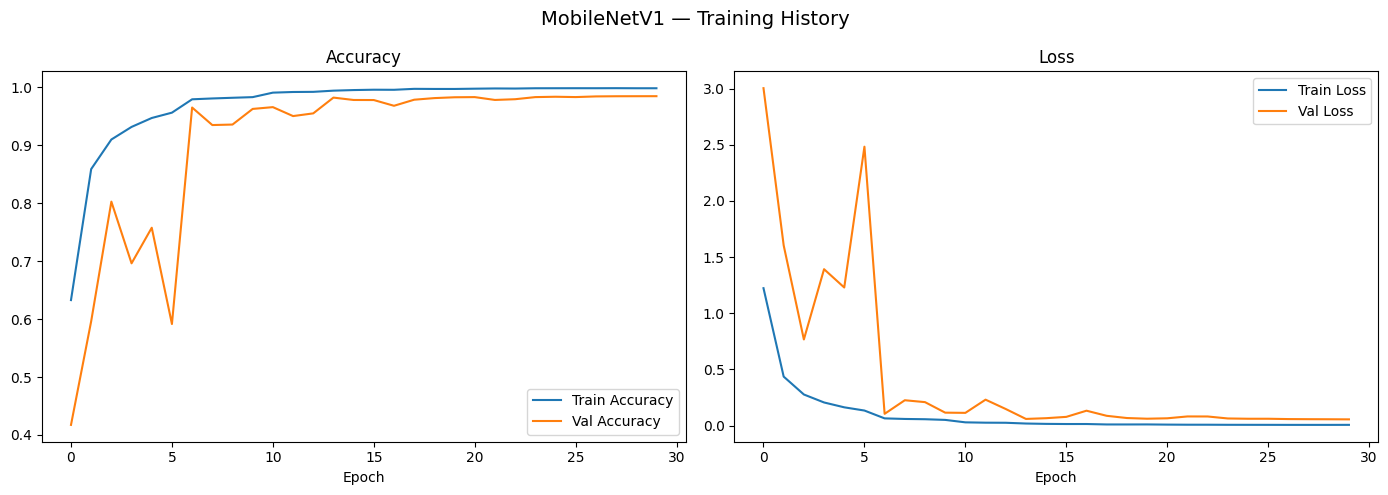

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MobileNetV1 — Training History', fontsize=14)

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'MobileNetV1_history.png'), dpi=150)
plt.show()

## 10. Evaluation (Validation Set)

In [25]:
print('Evaluating on validation set …')
y_true, y_pred = [], []

for x_batch, y_batch in valid_ds:
    preds = model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

with open(os.path.join(OUT_DIR, 'MobileNetV1_classification_report.txt'), 'w') as f:
    f.write(report)

eval_accuracy = np.sum(np.array(y_true) == np.array(y_pred)) / len(y_true)
print(f'Evaluation Accuracy: {eval_accuracy:.4f}')

Evaluating on validation set …
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9921    0.9960       504
                                 Apple___Black_rot     0.9920    1.0000    0.9960       497
                          Apple___Cedar_apple_rust     0.9932    1.0000    0.9966       440
                                   Apple___healthy     0.9708    0.9920    0.9813       502
                               Blueberry___healthy     0.9978    0.9978    0.9978       454
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9857    0.9928       421
                 Cherry_(including_sour)___healthy     0.9806    1.0000    0.9902       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9784    0.9927    0.9855       410
                       Corn_(maize)___Common_rust_     0.9979    0.9979    0.9979       477
               Corn_(maize)___Northern_Leaf_Blig

## 11. Confusion Matrix

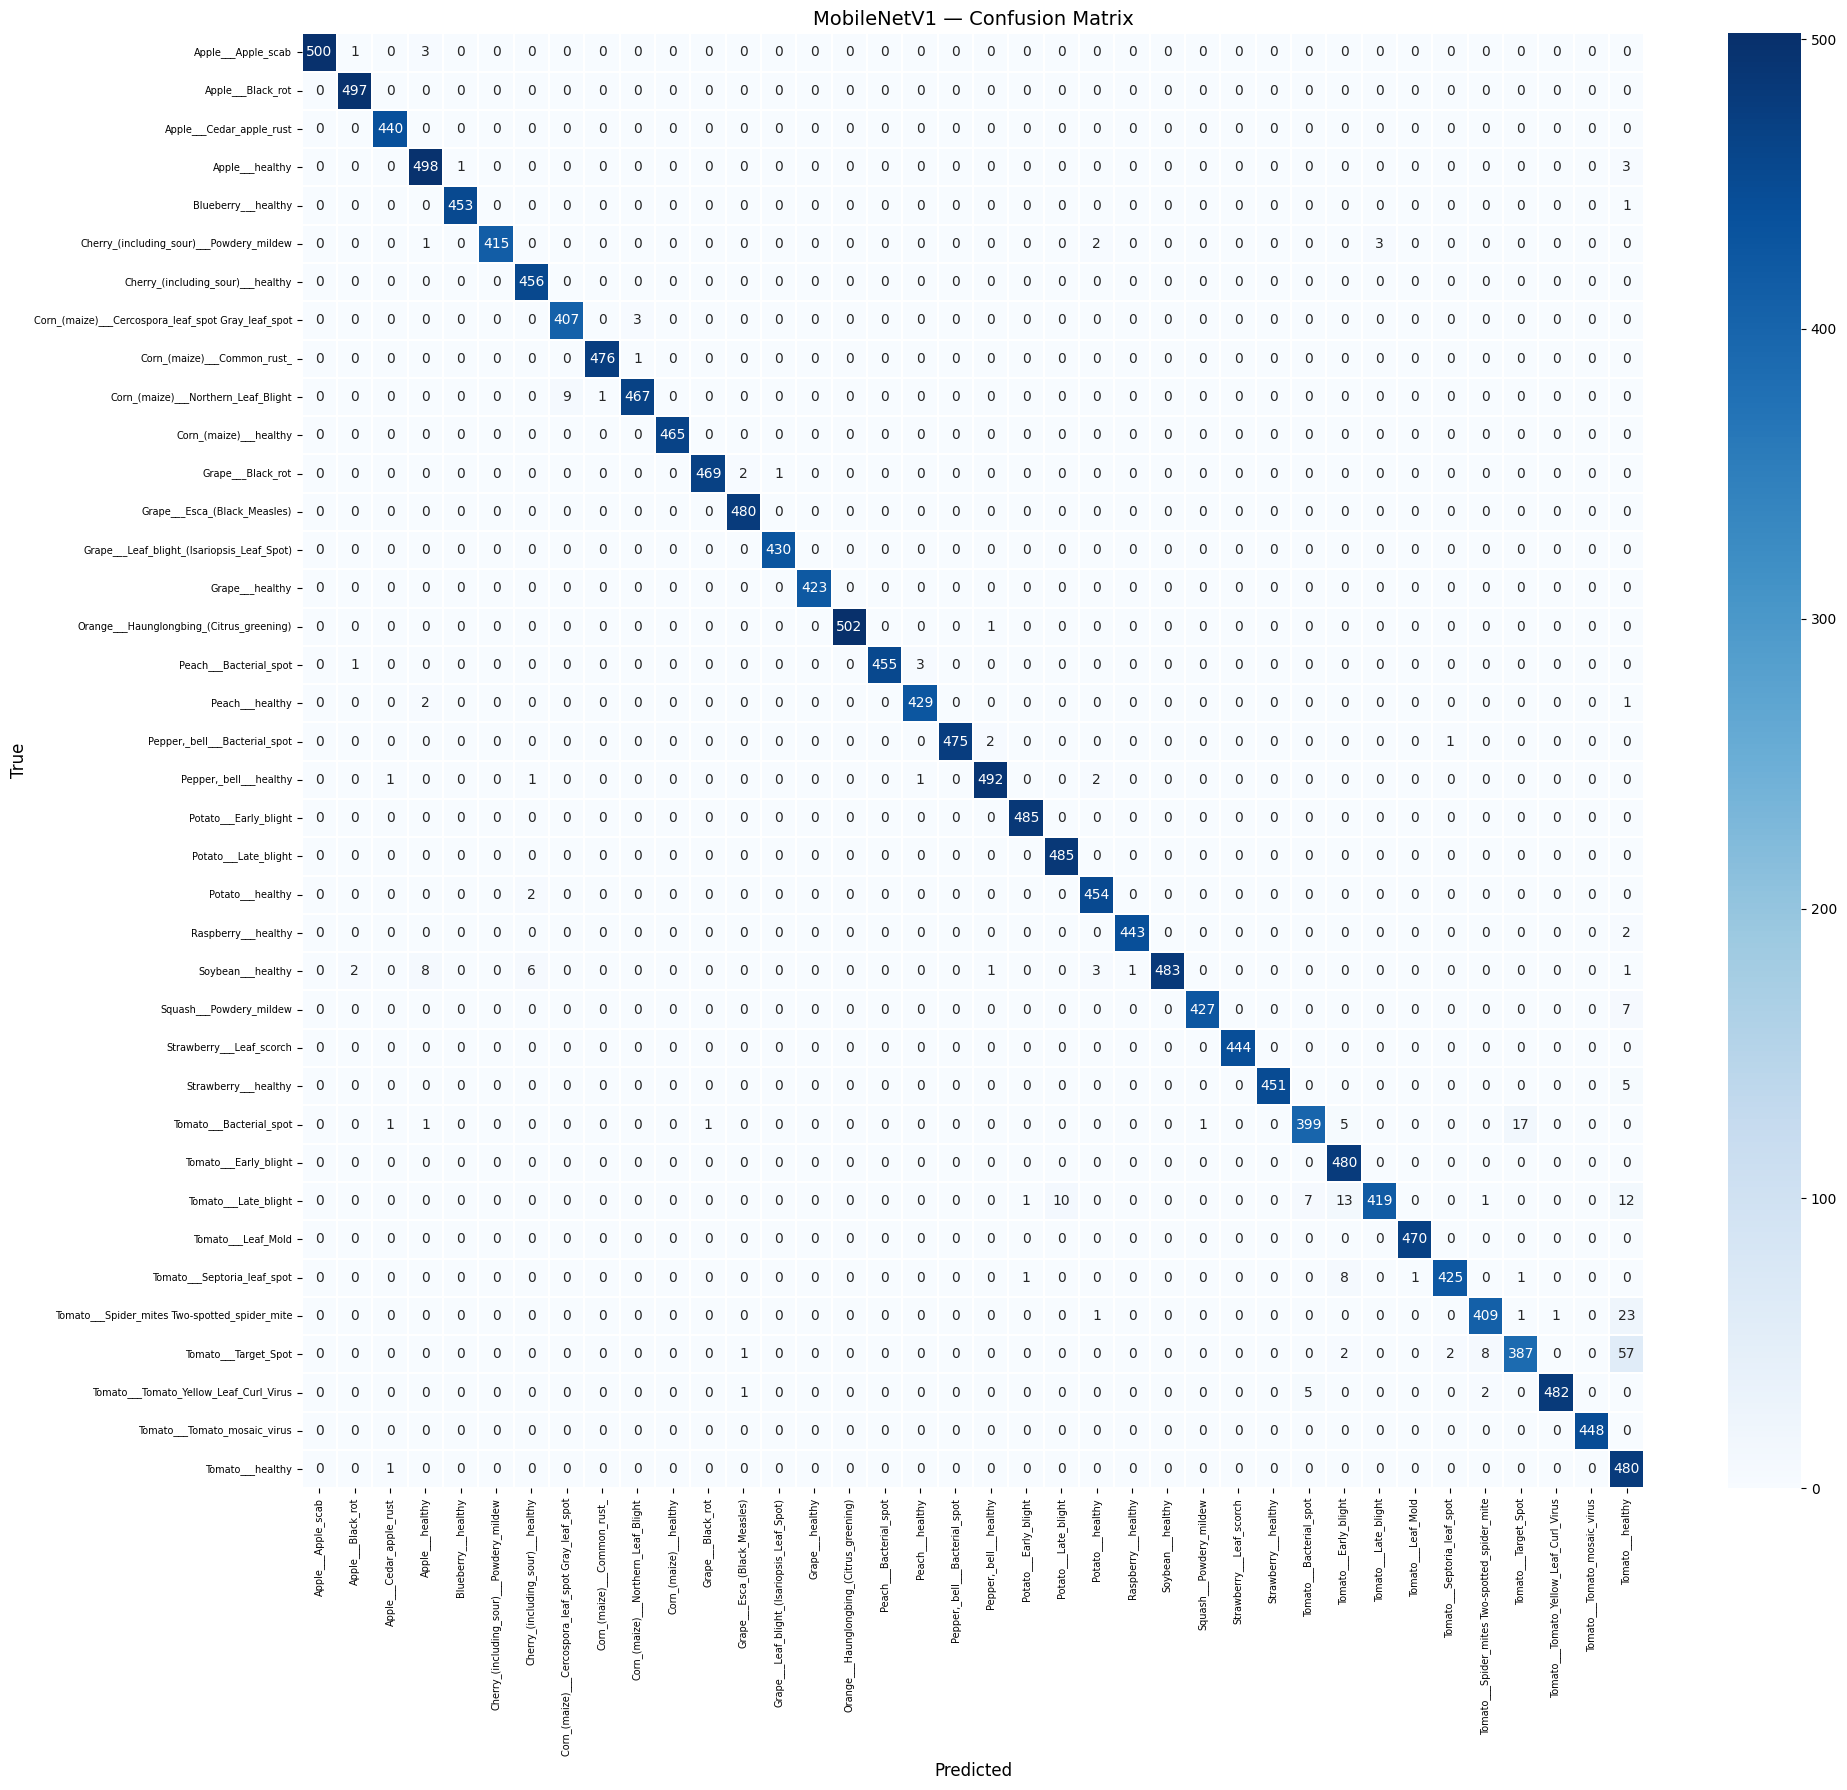

In [26]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    ax=ax, linewidths=0.3,
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True',      fontsize=12)
ax.set_title('MobileNetV1 — Confusion Matrix', fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'MobileNetV1_confusion_matrix.png'), dpi=150)
plt.show()

## 12. Save Model & Results

In [27]:
model.save(os.path.join(OUT_DIR, 'MobileNetV1_final.keras'))

result = {
    'best_val_accuracy': round(max(history.history['val_accuracy']), 4),
    'eval_accuracy':     round(eval_accuracy, 4),
    'train_time_min':    round(elapsed_min, 2),
    'epochs_run':        len(history.history['loss']),
}
with open(os.path.join(OUT_DIR, 'result.json'), 'w') as f:
    json.dump(result, f, indent=2)

print('\n📋 Final Results:')
for k, v in result.items():
    print(f'  {k}: {v}')
print(f'\n💾 All outputs saved to: {OUT_DIR}')


📋 Final Results:
  best_val_accuracy: 0.9845
  eval_accuracy: 0.9845
  train_time_min: 124.02
  epochs_run: 30

💾 All outputs saved to: D:\Leaf dataset 2\outputs\MobileNetV1
